# Gaussian Process Distance-Dependent Expression Analysis

This notebook fits Gaussian Process models to test whether gene expression varies as a 
function of distance from ligand knockdown cells. Two GP models are compared via 
likelihood ratio test:
- **RBF kernel**: captures smooth distance-dependent trends
- **Constant (Bias) kernel**: null model with no distance dependence

Uses GPy for GP fitting with fixed empirical noise (SEM² from pseudobulk bins).


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown", "h5py", "scipy", 
                "matplotlib", "pandas", "numpy", "GPy"])


In [ ]:
import os, warnings, time
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import chi2
from scipy.sparse import csr_matrix
import GPy

warnings.filterwarnings('ignore')

DATA_DIR = 'data'
OUTPUT_DIR = 'output'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

CATATAC_PATH = os.path.join(DATA_DIR, 'all_lanes_CATATAC.h5mu')
DRIVE_ID = '1NZzzEX9zHSj5Cp5ewuHRataW0jkIA-bo'


## 1. Download data

In [ ]:
if not os.path.exists(CATATAC_PATH):
    import gdown
    gdown.download(id=DRIVE_ID, output=CATATAC_PATH, quiet=False)
else:
    print(f"Data exists at {CATATAC_PATH}")


## 2. Load data and compute distances

In [ ]:
def read_sparse(grp):
    data = grp['data'][:]
    indices = grp['indices'][:]
    indptr = grp['indptr'][:]
    shape = tuple(grp.attrs['shape'])
    enc = grp.attrs.get('encoding-type', b'csr_matrix')
    if isinstance(enc, bytes): enc = enc.decode()
    if 'csc' in enc:
        from scipy.sparse import csc_matrix
        return csc_matrix((data, indices, indptr), shape=shape)
    return csr_matrix((data, indices, indptr), shape=shape)

def read_cat(grp):
    if isinstance(grp, h5py.Dataset):
        return np.array([v.decode() if isinstance(v, bytes) else v for v in grp[:]])
    cats = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['categories'][:]])
    codes = grp['codes'][:]
    return cats[codes]

print("Loading data...")
with h5py.File(CATATAC_PATH, 'r') as f:
    target_calls = read_cat(f['obs']['target_call'])
    eb_clusters = read_cat(f['obs']['EB_manual_clustering'])
    sp1 = np.array(f['obs']['SPATIAL_1'][:], dtype=float)
    sp2 = np.array(f['obs']['SPATIAL_2'][:], dtype=float)
    spatial = np.column_stack([sp1, sp2])

    rna_X = read_sparse(f['mod']['rna']['layers']['log1p_normalized'])
    gene_names = np.array([v.decode() if isinstance(v, bytes) else v for v in f['mod']['rna']['var']['_index'][:]])

print(f"Loaded {len(target_calls)} cells, {len(gene_names)} genes")

# Compute within-EB distances for WNT5A
TARGET = 'WNT5A'
excluded = {'Unassigned', 'No_CRISPR_data', 'Non-Targeting'}
kd_mask = target_calls == TARGET
non_kd_mask = np.array([t not in excluded and t != TARGET for t in target_calls])

distances = np.full(len(target_calls), np.inf)
for eb in np.unique(eb_clusters):
    eb_m = eb_clusters == eb
    ref = kd_mask & eb_m
    query = non_kd_mask & eb_m
    if ref.sum() < 1 or query.sum() < 1: continue
    tree = KDTree(spatial[ref])
    d, _ = tree.query(spatial[query])
    distances[np.where(query)[0]] = d

valid = non_kd_mask & (distances <= 300)
valid_idx = np.where(valid)[0]
print(f"{TARGET}: {kd_mask.sum()} KD cells, {valid.sum()} non-KD cells within 300µm")


Loading data...
Loaded 17043 cells, 29562 genes
WNT5A: 403 KD cells, 9498 non-KD cells within 300µm


## 3. Compute 10 µm binned pseudobulk

In [ ]:
# 30 bins of 10µm each
BINS = [(i*10, (i+1)*10) for i in range(30)]
BIN_MIDS = np.array([lo + 5 for lo, hi in BINS])

bin_cells = {}
bin_counts = []
for i, (lo, hi) in enumerate(BINS):
    if i == len(BINS) - 1:
        mask = valid & (distances >= lo) & (distances <= hi)
    else:
        mask = valid & (distances >= lo) & (distances < hi)
    bin_cells[i] = np.where(mask)[0]
    bin_counts.append(len(bin_cells[i]))

print(f"Bin counts: {bin_counts}")

# Detection filter
all_cells = np.concatenate([bin_cells[i] for i in range(30)])
det = np.array((rna_X[all_cells] != 0).mean(axis=0)).ravel()
det_pass = np.where(det > 0.05)[0]
print(f"Genes passing 5% detection: {len(det_pass)}")

# Compute pseudobulk means and SEMs
X = BIN_MIDS.reshape(-1, 1)
means = np.zeros((30, len(det_pass)))
sems = np.zeros((30, len(det_pass)))

for i in range(30):
    cells = bin_cells[i]
    vals = rna_X[cells][:, det_pass].toarray()
    means[i] = vals.mean(axis=0)
    sems[i] = vals.std(axis=0) / np.sqrt(len(cells))

# Fixed noise per gene: mean of SEM² across bins
mean_sem_sq = (sems**2).mean(axis=0)
print(f"Noise variance range: {mean_sem_sq.min():.6f} - {mean_sem_sq.max():.6f}")


Bin counts: [75, 232, 353, 421, 468, 515, 533, 528, 508, 459, 473, 443, 436, 458, 386, 390, 376, 342, 298, 282, 230, 237, 199, 166, 144, 148, 106, 103, 93, 96]
Genes passing 5% detection: 10789
Noise variance range: 0.000228 - 0.014159


## 4. Fit GP models (RBF vs constant)

In [ ]:
# Save preprocessed data and run GP fitting as subprocess
# (fitting ~10,789 models takes ~18 minutes, too long for notebook cell timeout)

import pickle, subprocess, sys

# Save inputs for the fitting script
np.savez(os.path.join(OUTPUT_DIR, 'gp_inputs.npz'),
         X=X, means=means, sems=sems, mean_sem_sq=mean_sem_sq,
         detection=det[det_pass], gene_indices=det_pass,
         gene_names=gene_names[det_pass], bin_counts=np.array(bin_counts))

# Write the fitting script
script = '''
import os, warnings, time
os.environ['MPLBACKEND'] = 'Agg'
import numpy as np
from scipy.stats import chi2
import GPy

warnings.filterwarnings('ignore')
out = 'output'
z = np.load(out + '/gp_inputs.npz', allow_pickle=True)
X = z['X']; means = z['means']; sems = z['sems']
noises = z['mean_sem_sq']; genes = z['gene_names'].astype(str)

results = []; t = time.time()
for k, gene in enumerate(genes):
    Y = means[:, k:k+1]; noise = float(noises[k])
    kr = GPy.kern.RBF(1, variance=1.0, lengthscale=50.0)
    mr = GPy.models.GPRegression(X, Y, kr)
    mr.Gaussian_noise.variance = noise; mr.Gaussian_noise.variance.fix()
    mr.optimize(messages=False, max_iters=1000)
    kc = GPy.kern.Bias(1, variance=1.0)
    mc = GPy.models.GPRegression(X, Y, kc)
    mc.Gaussian_noise.variance = noise; mc.Gaussian_noise.variance.fix()
    mc.optimize(messages=False, max_iters=1000)
    llr = float(mr.log_likelihood()); llc = float(mc.log_likelihood())
    lr = max(0.0, 2*(llr - llc)); p = float(chi2.sf(lr, 1))
    edge = mr.predict(np.array([[5.0],[295.0]]))[0].ravel()
    results.append(dict(gene=gene, ll_rbf=llr, ll_const=llc, lr_stat=lr, pval=p,
        rbf_lengthscale=float(kr.lengthscale), rbf_variance=float(kr.variance),
        noise_variance=noise, direction='increasing' if edge[1]>edge[0] else 'decreasing'))
    if (k+1) % 2000 == 0: print(f"  {k+1}/{len(genes)}, {time.time()-t:.0f}s", flush=True)

# FDR
pvals = np.array([r['pval'] for r in results])
order = np.argsort(pvals); ranked = pvals[order]; m = len(pvals)
adj = np.minimum.accumulate((ranked*m/np.arange(1,m+1))[::-1])[::-1]
adj = np.minimum(adj, 1.0); fdr = np.empty(m); fdr[order] = adj
for r, q in zip(results, fdr): r['fdr'] = float(q)
results.sort(key=lambda r: (r['fdr'], r['pval'], -r['lr_stat']))

import pickle
with open(out + '/gp_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print(f"Done: {len(results)} genes, {sum(1 for r in results if r['fdr']<0.05)} significant, {time.time()-t:.0f}s")
'''

with open('fit_gp.py', 'w') as f:
    f.write(script)

print("Running GP fitting (this takes ~18 minutes)...")
result = subprocess.run([sys.executable, 'fit_gp.py'], capture_output=True, text=True, timeout=1800)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

# Load results
with open(os.path.join(OUTPUT_DIR, 'gp_results.pkl'), 'rb') as f:
    results = pickle.load(f)

n_sig = sum(1 for r in results if r['fdr'] < 0.05)
print(f"\nSignificant at FDR < 0.05: {n_sig}")
print(f"\nTop 10:")
for r in results[:10]:
    print(f"  {r['gene']:<20s} LR={r['lr_stat']:7.1f}  FDR={r['fdr']:.2e}  "
          f"l={r['rbf_lengthscale']:.0f}µm  {r['direction']}")


Running GP fitting (this takes ~18 minutes)...
  2000/10789 genes, 204s elapsed
  4000/10789 genes, 408s elapsed
  6000/10789 genes, 612s elapsed
  8000/10789 genes, 816s elapsed
  10000/10789 genes, 1020s elapsed
Done: 10789 genes, 198 significant, 1101s

Significant at FDR < 0.05: 198

Top 10:
  CHST9                LR=   43.9  FDR=3.66e-07  l=620µm  increasing
  CHST11               LR=   39.3  FDR=1.48e-06  l=231µm  increasing
  ENSG00000248605      LR=   39.1  FDR=1.48e-06  l=686µm  increasing
  ENSG00000288880      LR=   36.5  FDR=4.20e-06  l=95µm   increasing
  SPRY4                LR=   35.5  FDR=5.50e-06  l=355µm  increasing
  ENSG00000219445      LR=   33.7  FDR=1.18e-05  l=758µm  increasing
  ENSG00000254277      LR=   32.9  FDR=1.40e-05  l=694µm  increasing
  NR2F1                LR=   32.8  FDR=1.40e-05  l=1465µm decreasing
  PDK1                 LR=   31.8  FDR=1.61e-05  l=598µm  increasing
  ABHD17B              LR=   31.7  FDR=1.61e-05  l=360µm  increasing


## 5. Plot top 8 genes

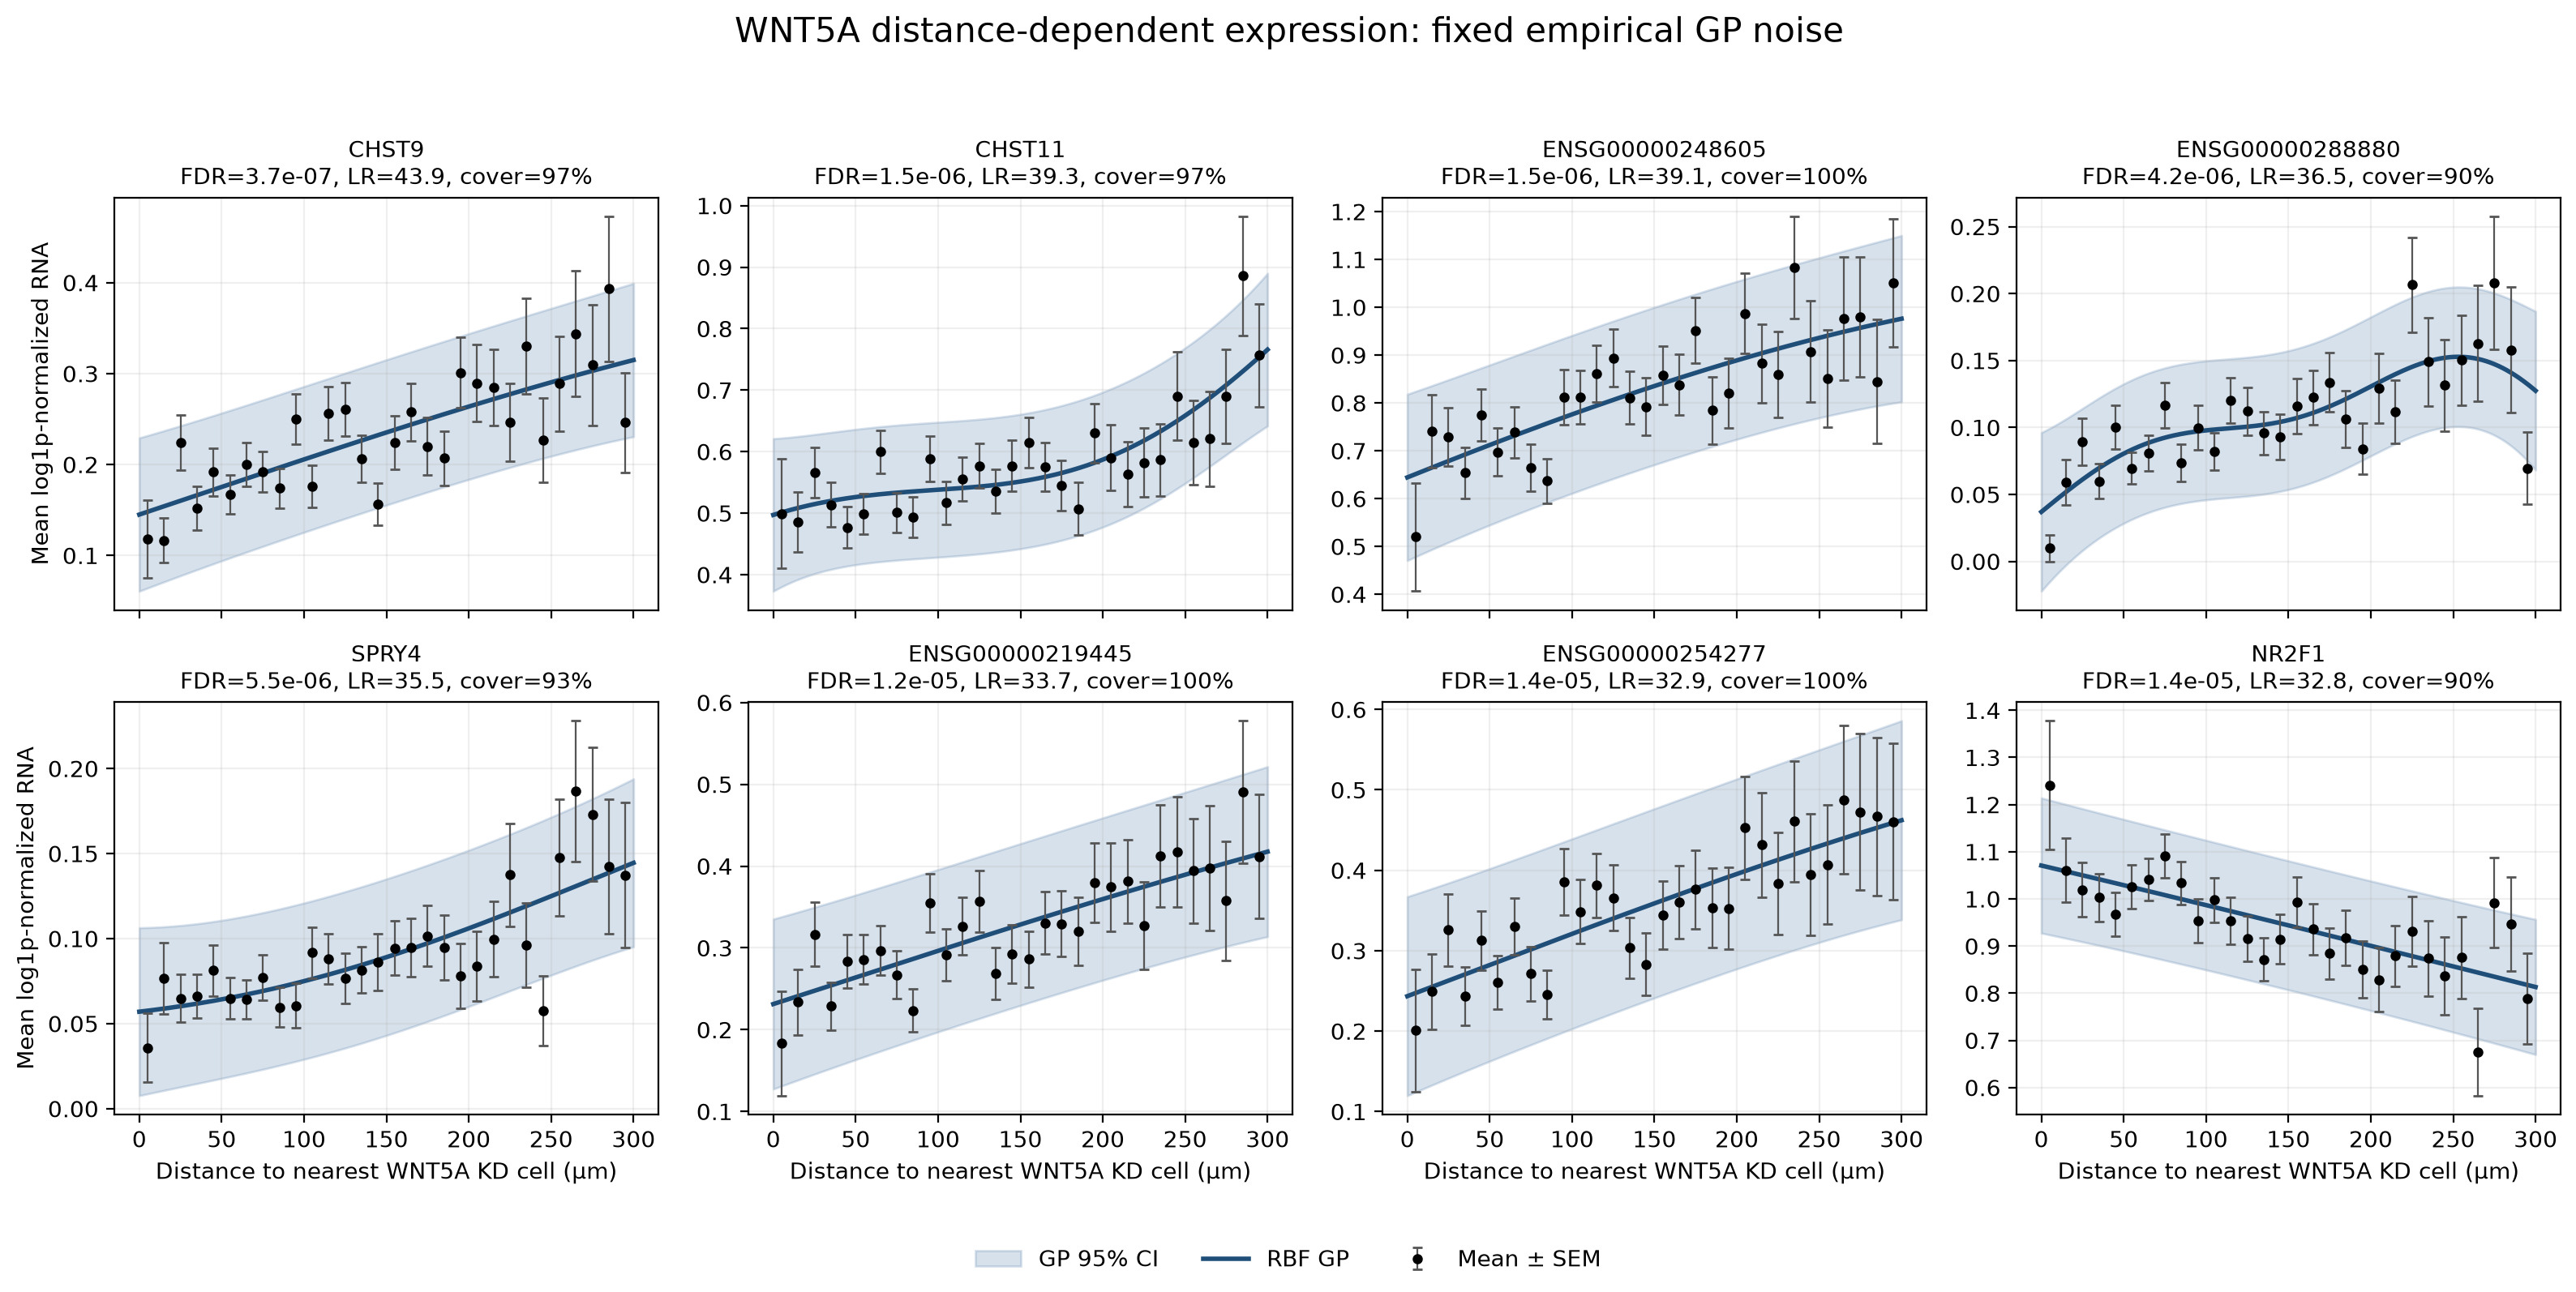

Figure saved. 198 significant genes at FDR < 0.05


In [ ]:
grid = np.linspace(0, 300, 601)[:, None]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True)

for j, (ax, r) in enumerate(zip(axes.ravel(), results[:8])):
    # Get pseudobulk data for this gene
    k = next(i for i, res in enumerate(results) if res['gene'] == r['gene'])
    gi = [i for i, res in enumerate(results) if res['gene'] == r['gene']][0]
    gene_col = np.where(gene_names[det_pass] == r['gene'])[0][0]
    Y = means[:, gene_col:gene_col+1]
    sem_col = sems[:, gene_col]
    noise = float(mean_sem_sq[gene_col])

    # Refit RBF for plotting (with saved hyperparams as init)
    kr = GPy.kern.RBF(1, variance=r['rbf_variance'], lengthscale=r['rbf_lengthscale'])
    mr = GPy.models.GPRegression(X, Y, kr)
    mr.Gaussian_noise.variance = noise
    mr.Gaussian_noise.variance.fix()
    # No need to re-optimize, just predict
    mu, var = mr.predict(grid)
    sd = np.sqrt(np.maximum(var[:, 0], 0))

    # Coverage
    mu_at_X, var_at_X = mr.predict(X)
    sd_at_X = np.sqrt(np.maximum(var_at_X[:, 0], 0))
    covered = np.mean((Y[:, 0] >= mu_at_X[:, 0] - 1.96*sd_at_X) & 
                       (Y[:, 0] <= mu_at_X[:, 0] + 1.96*sd_at_X))

    # Plot
    ax.fill_between(grid[:, 0], mu[:, 0] - 1.96*sd, mu[:, 0] + 1.96*sd,
                    color='#4C78A8', alpha=0.22, label='GP 95% CI')
    ax.plot(grid[:, 0], mu[:, 0], color='#1f4e79', lw=2, label='RBF GP')
    ax.errorbar(X[:, 0], Y[:, 0], yerr=sem_col, fmt='o', ms=3.5, color='black',
               ecolor='#555555', elinewidth=0.8, capsize=2, label='Mean ± SEM')

    ax.set_title(f"{r['gene']}\nFDR={r['fdr']:.2g}, LR={r['lr_stat']:.1f}, cover={covered:.0%}",
                fontsize=10)
    ax.grid(alpha=0.2)

for ax in axes[-1]:
    ax.set_xlabel(f'Distance to nearest {TARGET} KD cell (µm)')
for ax in axes[:, 0]:
    ax.set_ylabel('Mean log1p-normalized RNA')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
fig.suptitle(f'{TARGET} distance-dependent expression: fixed empirical GP noise', fontsize=15)
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
fig.savefig(os.path.join(OUTPUT_DIR, 'gpy_fits_WNT5A.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to {OUTPUT_DIR}/gpy_fits_WNT5A.png")
